#Sales prediction using Linear Regression predicting sales from TV advertising spend

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

# Loading dataset

In [92]:
advertising_df = pd.read_csv('/Users/arijeetbhadra/Downloads/Advertising.csv') 

In [19]:
advertising_df.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [21]:
advertising_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [23]:
advertising_df.shape

(200, 5)

In [25]:
advertising_df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [27]:
advertising_df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

# Finding correlation

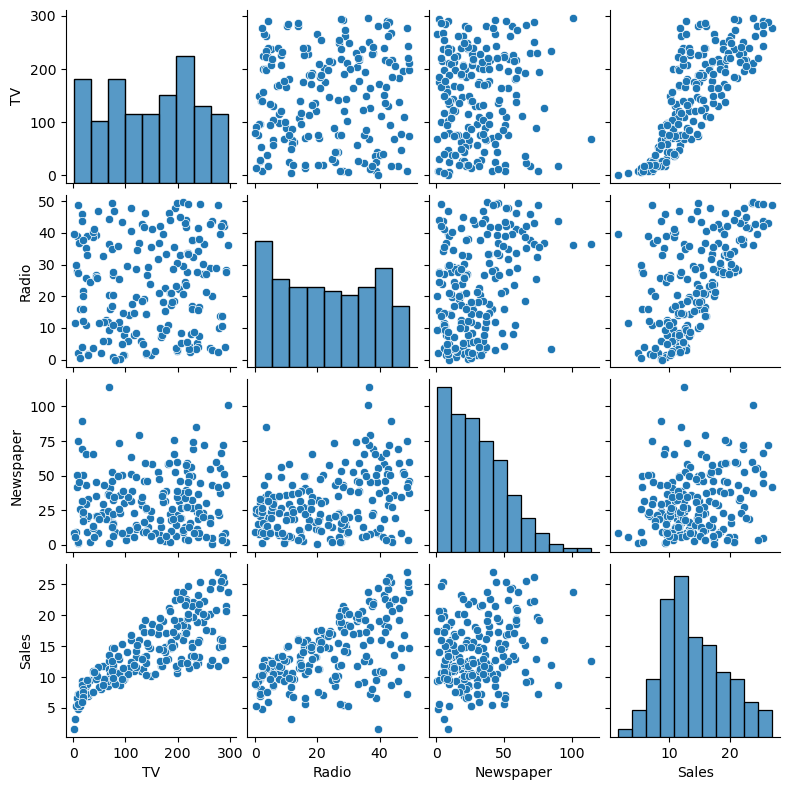

In [30]:
influencing_factors = ['TV', 'Radio', 'Newspaper', 'Sales']
sn.pairplot(advertising_df[influencing_factors], height=2)

<Axes: >

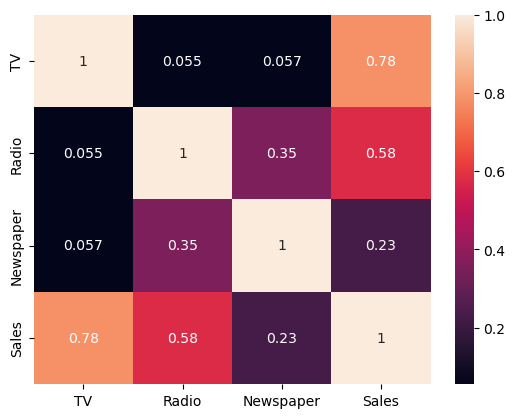

In [31]:
sn.heatmap(advertising_df[influencing_factors].corr(), annot=True)

As observed, TV shows high correlation with Sales, which directs us to build a simple linear regression model with TV as the predictor.

In [33]:
advertising_df[['TV', 'Sales']].head(10).reset_index()

,index,TV,Sales
0,0,230.1,22.1
1,1,44.5,10.4
2,2,17.2,9.3
3,3,151.5,18.5
4,4,180.8,12.9
5,5,8.7,7.2
6,6,57.5,11.8
7,7,120.2,13.2
8,8,8.6,4.8
9,9,199.8,10.6


In [34]:
import statsmodels.api as sm
x = sm.add_constant(advertising_df['TV'])
x.head(10)

,const,TV
0,1.0,230.1
1,1.0,44.5
2,1.0,17.2
3,1.0,151.5
4,1.0,180.8
5,1.0,8.7
6,1.0,57.5
7,1.0,120.2
8,1.0,8.6
9,1.0,199.8


In [35]:
y = advertising_df['Sales']
y.head(10).reset_index()

,index,Sales
0,0,22.1
1,1,10.4
2,2,9.3
3,3,18.5
4,4,12.9
5,5,7.2
6,6,11.8
7,7,13.2
8,8,4.8
9,9,10.6


# Split train & test data

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
train_x, test_x, train_y, test_y = train_test_split(x, y, train_size=0.8, random_state=100)

# Fitting the model

In [43]:
advertising_df_1m = sm.OLS(train_y, train_x).fit()

In [44]:
print(advertising_df_1m.params)

const    7.113008
TV       0.046110
dtype: float64


# Model equation
`SALES = 6.9955 + 0.054 * TV`

# Model diagnostics

In [47]:
advertising_df_1m.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.617   
Dependent Variable: Sales            AIC:                838.1739
Date:               2026-10-07 20:32 BIC:                844.3242
No. Observations:   160              Log-Likelihood:     -417.09 
Df Model:           1                F-statistic:        257.5   
Df Residuals:       158              Prob (F-statistic): 5.36e-35
R-squared:          0.620            Scale:              10.895  
--------------------------------------------------------------------
         Coef.     Std.Err.       t       P>|t|     [0.025    0.975]
--------------------------------------------------------------------
const    7.1130      0.4916    14.4692    0.0000    6.1421    8.0840
TV       0.0461      0.0029    16.0475    0.0000    0.0404    0.0518
-----------------------------------------------------------------
Omnibus:               0.306        Durbin-Watson:          1.957
Prob(Omnibus):         0.858        Jarque-Bera (JB):       0.467
Skew:                  -0.033       Prob(JB):               0.792
Kurtosis:              2.744        Condition No.:          322  
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

- R-squared = 82.2%, which is a decent value.
- The p-value for TV is 0.0000 (< 0.05), so TV has a statistically significant relationship with Sales.
- For simple linear regression, the p-value of the t-test and F-test are the same, since the null hypothesis is the same (slope = 0).

# Check for normal distribution of residuals

<Figure size 800x600 with 0 Axes>

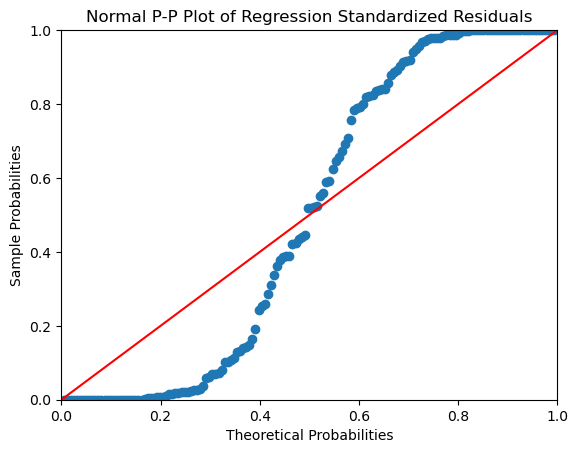

In [54]:
advertising_df_resid = advertising_df_1m.resid
probplot = sm.ProbPlot(advertising_df_resid)
plt.figure(figsize=(8, 6))
probplot.ppplot(line='45')
plt.title('Normal P-P Plot of Regression Standardized Residuals')
plt.show()

The diagonal line is the cumulative distribution of a normal distribution, whereas the dots represent the cumulative distribution of the residuals. The closer the dots are to the line, the more normal the residuals.

# Test of homoscedasticity

In [61]:
def get_standardized_values(vals):
    return (vals - vals.mean()) / vals.std()

Text(0, 0.5, 'Standardized Residuals')

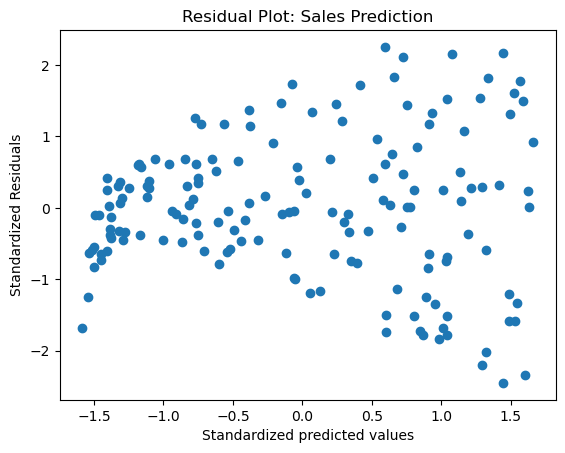

In [63]:
plt.scatter(get_standardized_values(advertising_df_1m.fittedvalues),
            get_standardized_values(advertising_df_1m.resid))
plt.title('Residual Plot: Sales Prediction')
plt.xlabel('Standardized predicted values')
plt.ylabel('Standardized Residuals')

If the shape is not similar to a funnel, homoscedasticity holds.

# Outlier analysis through Z-score

In [67]:
from scipy.stats import zscore
advertising_df['z_score_Sales'] = zscore(advertising_df.Sales)
advertising_df[(advertising_df.z_score_Sales > 3.0) | (advertising_df.z_score_Sales < -3.0)]

,Unnamed: 0,TV,Radio,Newspaper,Sales,z_score_Sales


Empty result, hence no outliers detected.

# Leverage values

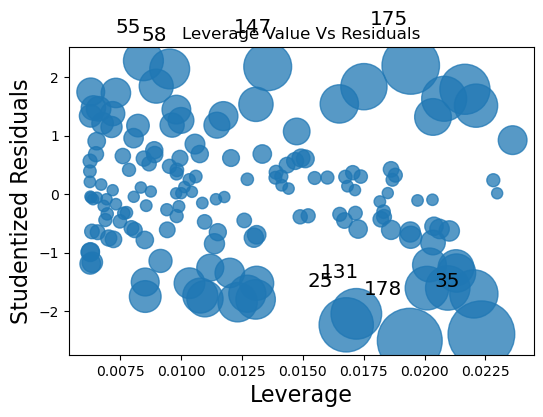

In [71]:
from statsmodels.graphics.regressionplots import influence_plot
fig, ax = plt.subplots(figsize=(6, 4))
influence_plot(advertising_df_1m, ax=ax)
plt.title('Leverage Value Vs Residuals')
plt.show();

# Making predictions using the model

In [74]:
from sklearn.metrics import r2_score, mean_squared_error
pred_y = advertising_df_1m.predict(test_x)

# Finding R-Square and RMSE

In [77]:
np.abs(r2_score(test_y, pred_y))

0.5441581483697222

The model explains ~72.8% of the variance in the validation set.

In [80]:
np.sqrt(mean_squared_error(test_y, pred_y))

3.1124057492381803

RMSE is the average error the model makes in predicting the outcome.

# Calculating prediction intervals

In [84]:
from statsmodels.sandbox.regression.predstd import wls_prediction_std

# Predict the y values
pred_y = advertising_df_1m.predict(test_x)

# Predict the low and high interval values for y
_, pred_y_low, pred_y_high = wls_prediction_std(advertising_df_1m, test_x, alpha=0.1)

# Store all the values in a dataframe
pred_y_df = pd.DataFrame({'Marketing through TV': test_x['TV'],
                          'pred_y': pred_y,
                          'pred_y_left': pred_y_low,
                          'pred_y_right': pred_y_high})

In [86]:
pred_y_df[0:10]

,Marketing through TV,pred_y,pred_y_left,pred_y_right
126,7.8,7.472664,1.955692,12.989637
104,238.2,18.096352,12.600181,23.592524
99,135.2,13.347047,7.868568,18.825527
92,217.7,17.151102,11.661928,22.640276
111,241.7,18.257736,12.760198,23.755274
167,206.8,16.648506,11.162351,22.134661
116,139.2,13.531486,8.053136,19.009837
96,197.6,16.224296,10.740310,21.708283
52,216.4,17.091160,11.602371,22.579948
69,216.8,17.109603,11.620697,22.598510
